In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

c:\Users\Shubhankar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [5]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Dataset path
data_dir = r"C:\Users\Shubhankar\Downloads\archive (3)\Alzheimer_MRI_4_classes_dataset"

In [7]:

# Load processor and define transforms
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

In [8]:
# Load dataset
full_dataset = ImageFolder(data_dir, transform=transform)
class_names = full_dataset.classes


In [9]:
# Split into train, val, test
train_size = int(0.7 * len(full_dataset))
val_size = int(0.2 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)


In [ ]:
# Load ViT model
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(class_names),
    ignore_mismatched_sizes=True
).to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [13]:
# Training
train_losses, val_losses, train_accs, val_accs = [], [], [], []

In [14]:
import torch
print(torch.cuda.is_available())            # Should return True
print(torch.cuda.get_device_name(0))        # Should print your GPU name


True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [15]:
best_val_acc = 0.0  # To track the best accuracy
model_save_path = "vit_alzheimer_best.pth"

for epoch in range(100):  # Adjust number of epochs as needed
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/100"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(total_loss)
    train_accs.append(train_acc)


Epoch 1/100:   0%|          | 0/280 [00:00<?, ?it/s]

Epoch 100/100: 100%|██████████| 280/280 [02:40<00:00,  1.74it/s]


In [25]:
# Final Stats
final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]

print("\n🧠 Final Training Summary:")
print(f"✅ Training Accuracy: {final_train_acc:.4f}")
print(f"✅ Validation Accuracy: {final_val_acc:.4f}")
print(f"🔻 Training Loss: {final_train_loss:.4f}")
print(f"🔻 Validation Loss: {final_val_loss:.4f}")



🧠 Final Training Summary:
✅ Training Accuracy: 1.0000
✅ Validation Accuracy: 0.9766
🔻 Training Loss: 0.0000
🔻 Validation Loss: 0.2497


In [37]:
# Save model
torch.save(model.state_dict(), "vit_alzeheimer.pth")

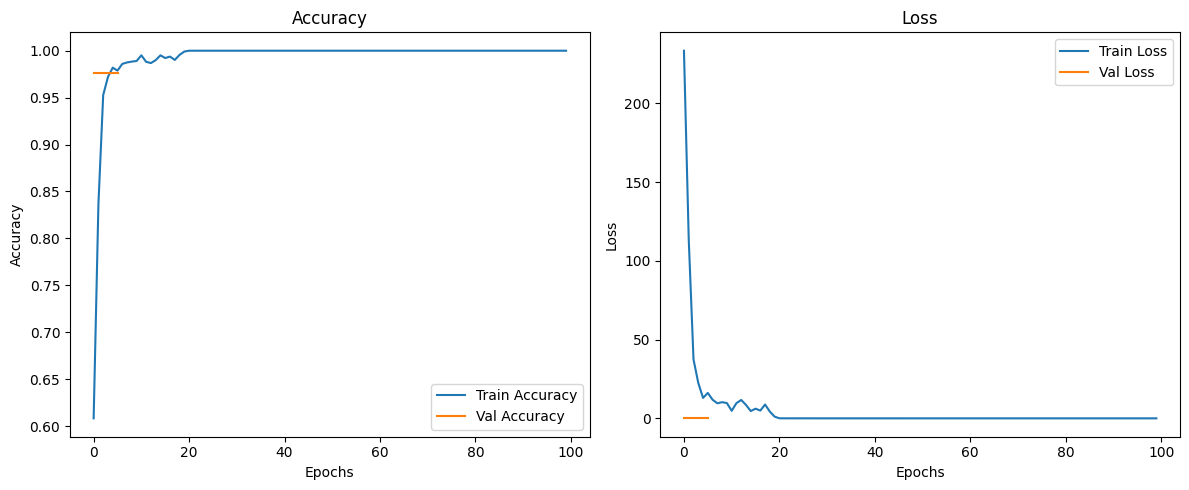

In [26]:

# Plotting Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:

# Final evaluation on test set
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.99      0.98      0.99       104
ModerateDemented       1.00      1.00      1.00         6
     NonDemented       0.97      1.00      0.98       336
VeryMildDemented       0.99      0.95      0.97       194

        accuracy                           0.98       640
       macro avg       0.99      0.98      0.98       640
    weighted avg       0.98      0.98      0.98       640



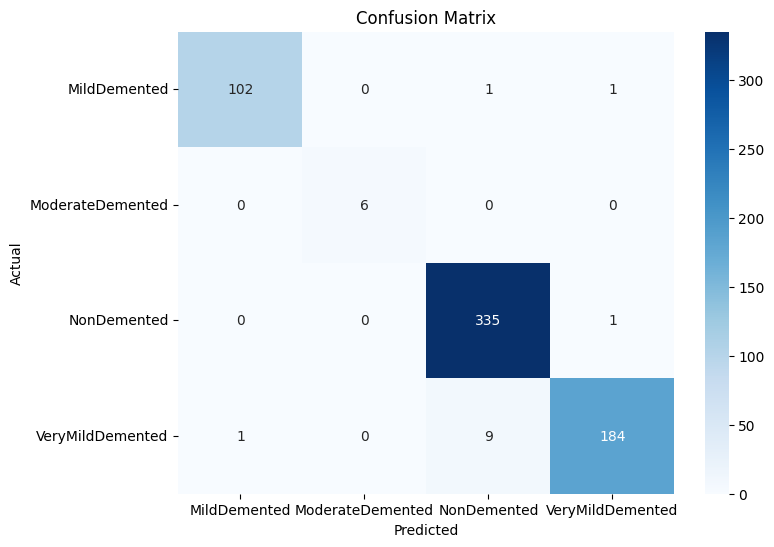

In [28]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

🖼️ Image: moderateDem6.jpg
✅ Predicted Class: ModerateDemented
📊 Confidence: 100.00%


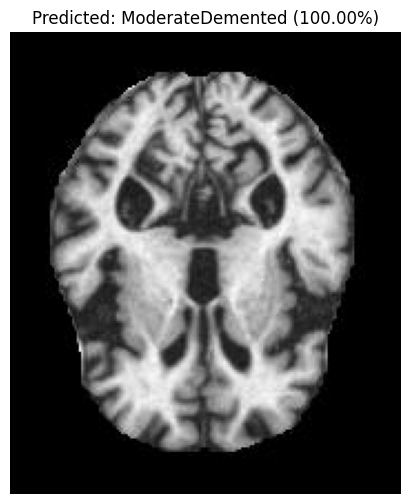

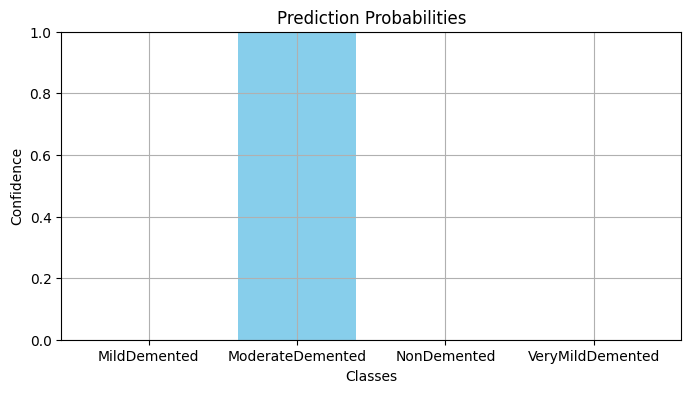

In [32]:
from PIL import Image
import torch.nn.functional as F
import os

image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\ModerateDemented\moderateDem6.jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: verymildDem1013.jpg
✅ Predicted Class: VeryMildDemented
📊 Confidence: 100.00%


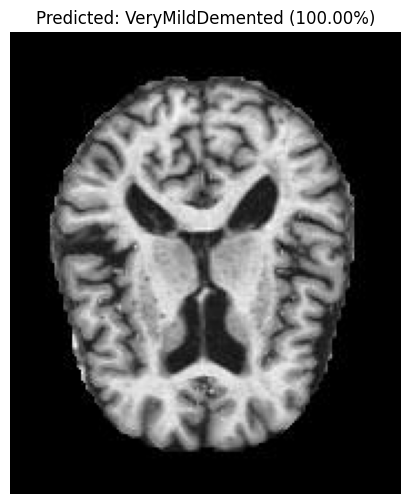

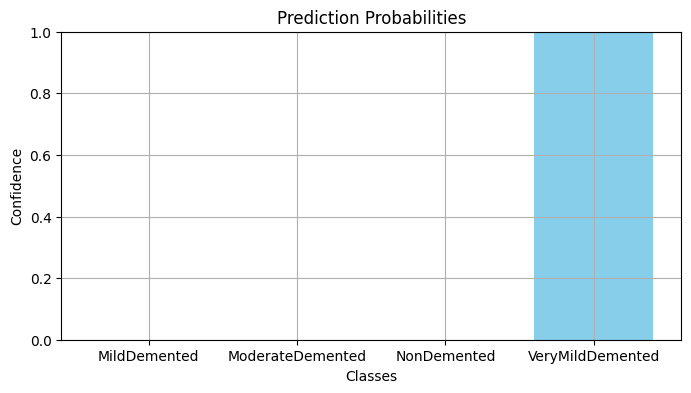

In [34]:
image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\VeryMildDemented\verymildDem1013.jpg" # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: 32.jpg
✅ Predicted Class: ModerateDemented
📊 Confidence: 100.00%


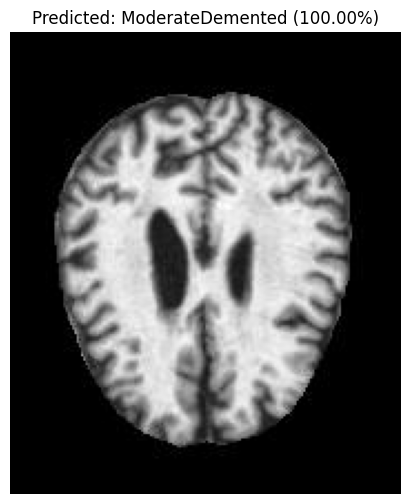

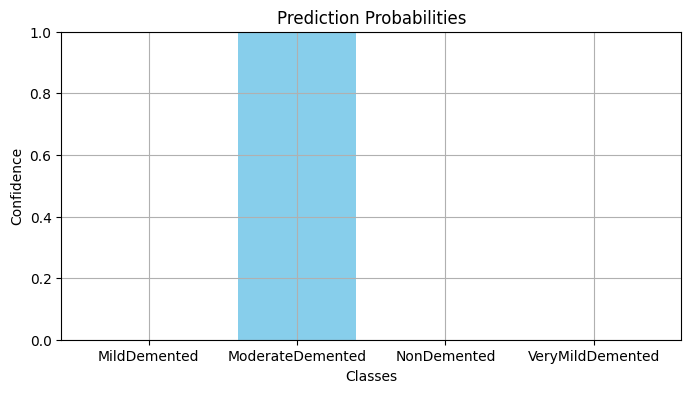

In [35]:
image_path = r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\ModerateDemented\32.jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


🖼️ Image: 29 (10).jpg
✅ Predicted Class: MildDemented
📊 Confidence: 100.00%


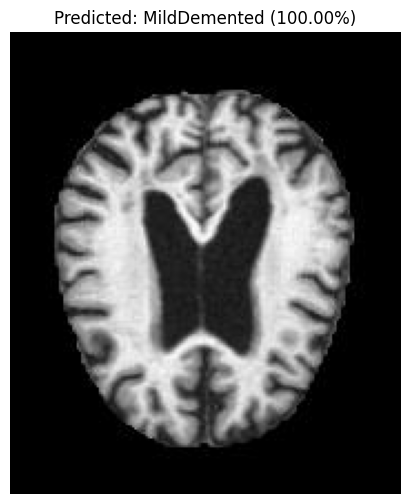

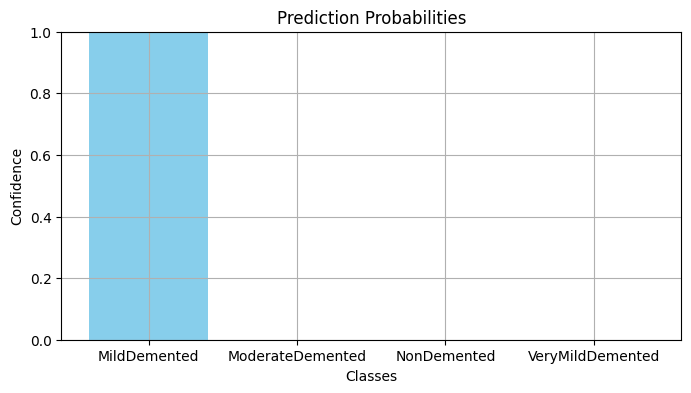

In [36]:
image_path =r"C:\Users\Shubhankar\Downloads\Alzheimers disease dataset\Alzheimers disease dataset\Alzheimer's dataset\OriginalDataset\MildDemented\29 (10).jpg"  # Replace with your test image path
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs).logits
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred_class_idx = probs.argmax()
    pred_class = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]

print(f"🖼️ Image: {os.path.basename(image_path)}")
print(f"✅ Predicted Class: {pred_class}")
print(f"📊 Confidence: {confidence*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence*100:.2f}%)")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Classes")
plt.ylabel("Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()
